# Datasets Combination

Merge all cleaned datasets into one

## A. List of datasets

### A.1. CrisisLexT6

### A.2. CrisisLexT26

### A.3. CrisisMMD

### A.4. CrisisNLP_R1

## B. Merge

### B.1. Columns

### B.1. Columns

In [69]:
from pathlib import Path
# import os
import pandas as pd

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

all_files = sorted(Path('datasets').rglob('*.csv'))
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# df = pd.read_csv(all_files[1])

Found 5 CSV files in the datasets directory.
 - datasets/ACL_ICWSM_2018.csv
 - datasets/CrisisLexT26.csv
 - datasets/CrisisLexT6.csv
 - datasets/CrisisMMD_v2.csv
 - datasets/CrisisNLP.csv


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135884 entries, 0 to 135883
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   tweet_id        135884 non-null  int64 
 1   tweet_text      135884 non-null  object
 2   relevant        135884 non-null  bool  
 3   event_type      135884 non-null  object
 4   event_name      135884 non-null  object
 5   dataset         135884 non-null  object
 6   original_label  135884 non-null  object
 7   country         135884 non-null  object
 8   year            135884 non-null  int64 
 9   meta            135884 non-null  object
dtypes: bool(1), int64(2), object(7)
memory usage: 9.5+ MB


In [71]:
df.describe()

,tweet_id,year
count,1.358840e+05,135884.000000
mean,4.969573e+17,1959.056357
std,2.124786e+17,328.389211
min,2.034409e+17,-1.000000
25%,2.973236e+17,2013.000000
50%,5.013115e+17,2014.000000
75%,5.926249e+17,2015.000000
max,9.320276e+17,2017.000000


In [72]:
df.head()

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."


Datasets List

In [73]:
df[df['dataset']=='Related and informative']

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta


<Axes: xlabel='dataset'>

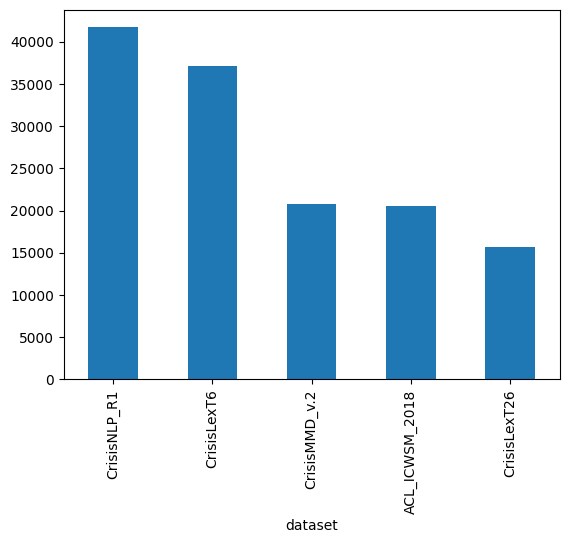

In [74]:
df['dataset'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

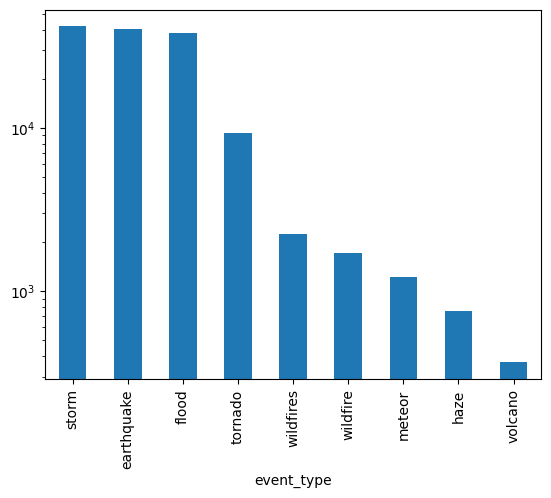

In [75]:
df['event_type'].value_counts().plot(kind='bar', logy=True)

Text(0.5, 1.0, 'Number of event_name entries for each event_type')

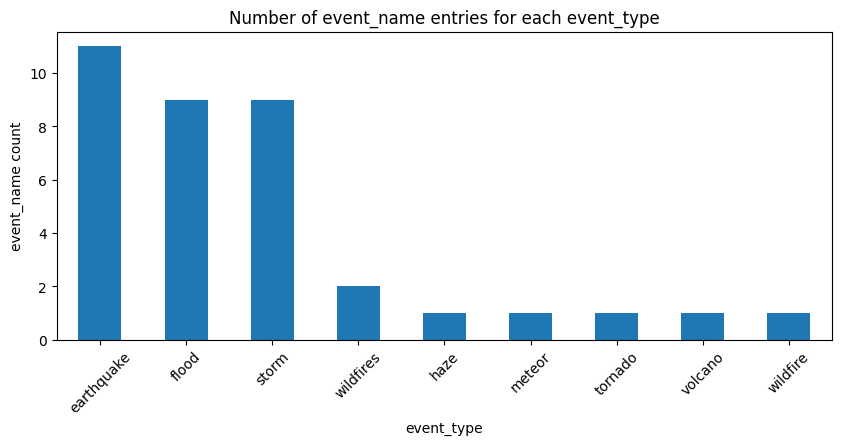

In [76]:
event_name_count_by_type = (
    df.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=45)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type')

In [77]:
event_name_count_by_type.head()

event_type
earthquake    11
flood          9
storm          9
wildfires      2
haze           1
Name: event_name, dtype: int64

<Axes: xlabel='relevant'>

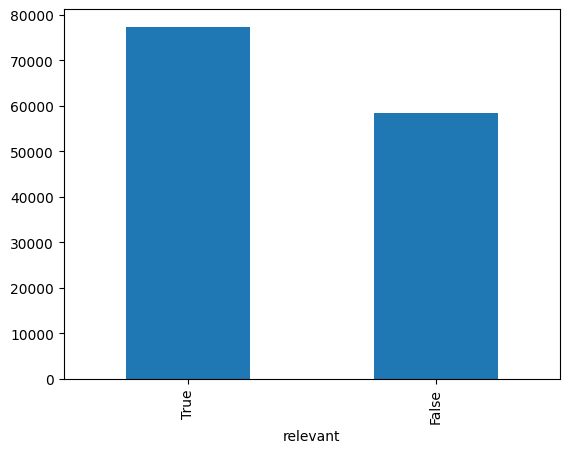

In [78]:
df['relevant'].value_counts().plot(kind='bar')